# **1. Perkenalan Dataset**

## Ringkasan Dataset Buy Now & Pay Later Fintech ML Dataset

Dataset ini merupakan data transaksi Buy Now, Pay Later (BNPL) yang bersifat sintetis. Terdapat 10.345 transaksi dari 6 negara selama periode 2023-2024. Dataset ini dirancang untuk membangun model prediksi risiko kredit dan default di industri fintech.

Target Variabel: default_flag
- 1 = Default (gagal bayar)
- 0 = Membayar tepat waktu

## Informasi File

- Nama file: Buy_Now_Pay_Now_BNPL_CreditRisk_Dataset.csv
- Ukuran: 1.17 MB
- Jumlah baris: 10.345
- Jumlah kolom: 17

## Sumber Dataset

Dataset ini tersedia di Kaggle:
https://www.kaggle.com/datasets/shree0910/buy-now-and-pay-later-fintech-ml-dataset

Dibuat oleh Shreyash Gade

# **2. Import Library**

In [110]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns

# Preprocessing & modeling (untuk persiapan)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# Settings
import os
import warnings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

In [111]:
# Memuat dataset dari file CSV
df = pd.read_csv('../Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv')

# Cek ukuran dataset
print(f"\nUkuran Dataset: {df.shape[0]} baris x {df.shape[1]} kolom")


Ukuran Dataset: 10345 baris x 17 kolom


In [112]:
# Melihat 5 baris pertama
print("5 Baris Pertama Dataset:")
df.head()

5 Baris Pertama Dataset:


,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk


In [113]:
# Melihat informasi dataset
print("\nInformasi Dataset:")
df.info()


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  object 
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  object 
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  object 
 13  transaction_date      10345 non-null  object 
 14  debt_to_income_ratio  10345 non-null  float64
 15 

In [114]:
# Melihat statistik deskriptif
print("\nStatistik Deskriptif:")
df.describe()


Statistik Deskriptif:


,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000
mean,5173.000000,38.559884,35053.381898,448.176124,3979.402721,7.477525,8.742774,1.015950,0.390527,5.524101,0.181071,198.534094
std,2986.488601,12.131789,27084.517277,136.518332,1500.828483,3.362867,6.781849,0.996726,0.487892,2.590364,0.124887,67.541384
min,1.000000,18.000000,5000.000000,300.000000,100.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000811,0.000000
25%,2587.000000,28.000000,12207.020000,332.000000,2990.720000,3.000000,2.000000,0.000000,0.000000,3.300000,0.080187,153.600000
50%,5173.000000,39.000000,23800.520000,403.000000,5000.000000,9.000000,9.000000,1.000000,0.000000,5.550000,0.138263,202.800000
75%,7759.000000,49.000000,55276.930000,547.000000,5000.000000,9.000000,14.000000,2.000000,1.000000,7.750000,0.268300,250.800000
max,10345.000000,59.000000,145767.120000,850.000000,5000.000000,12.000000,33.000000,7.000000,1.000000,10.000000,0.723460,398.000000


# **4. Exploratory Data Analysis (EDA)**

In [115]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
 
NUM_COLS = ['age', 'monthly_income', 'credit_score', 'purchase_amount',
            'bnpl_installments', 'repayment_delay_days', 'missed_payments',
            'app_usage_frequency', 'debt_to_income_ratio', 'risk_score']
CAT_COLS = ['employment_type', 'product_category', 'location', 'customer_segment']
TARGET   = 'default_flag'

In [116]:
print("=" * 60)
print("1. SHAPE & DTYPES")
print("=" * 60)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()
print(df.dtypes)
 
print("\n" + "=" * 60)
print("2. MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "Tidak ada missing values.")
 
print("\n" + "=" * 60)
print("3. DUPLICATED ROWS")
print("=" * 60)
print(f"Jumlah duplikat: {df.duplicated().sum()}")

1. SHAPE & DTYPES
Rows: 10345, Columns: 17

user_id                          int64
age                              int64
employment_type                 object
monthly_income                 float64
credit_score                     int64
purchase_amount                float64
product_category                object
bnpl_installments                int64
repayment_delay_days             int64
missed_payments                  int64
default_flag                     int64
app_usage_frequency            float64
location                        object
transaction_date        datetime64[ns]
debt_to_income_ratio           float64
risk_score                     float64
customer_segment                object
dtype: object

2. MISSING VALUES
Tidak ada missing values.

3. DUPLICATED ROWS
Jumlah duplikat: 0


In [117]:
print("\n" + "=" * 60)
print("4. STATISTIK DESKRIPTIF (NUMERIK)")
print("=" * 60)
print(df[NUM_COLS].describe().round(2).to_string())
 
print("\n" + "=" * 60)
print("5. DISTRIBUSI FITUR KATEGORIK")
print("=" * 60)
for col in CAT_COLS:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())


4. STATISTIK DESKRIPTIF (NUMERIK)
            age  monthly_income  credit_score  purchase_amount  bnpl_installments  repayment_delay_days  missed_payments  app_usage_frequency  debt_to_income_ratio  risk_score
count  10345.00        10345.00      10345.00         10345.00           10345.00              10345.00         10345.00             10345.00              10345.00    10345.00
mean      38.56        35053.38        448.18          3979.40               7.48                  8.74             1.02                 5.52                  0.18      198.53
std       12.13        27084.52        136.52          1500.83               3.36                  6.78             1.00                 2.59                  0.12       67.54
min       18.00         5000.00        300.00           100.00               3.00                  0.00             0.00                 1.00                  0.00        0.00
25%       28.00        12207.02        332.00          2990.72               3.00    

In [118]:
print("\n" + "=" * 60)
print("6. DISTRIBUSI TARGET (default_flag)")
print("=" * 60)
vc = df[TARGET].value_counts()
print(vc)
print(f"\nDefault rate: {df[TARGET].mean()*100:.2f}%")


6. DISTRIBUSI TARGET (default_flag)
default_flag
0    6305
1    4040
Name: count, dtype: int64

Default rate: 39.05%


In [119]:
print("\n" + "=" * 60)
print("7. SKEWNESS & OUTLIER (IQR)")
print("=" * 60)
rows = []
for col in NUM_COLS:
    skew = df[col].skew()
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    rows.append({'feature': col, 'skewness': round(skew, 3),
                 'outliers': n_out, 'outlier_%': round(n_out/len(df)*100, 2)})
print(pd.DataFrame(rows).set_index('feature').to_string())


7. SKEWNESS & OUTLIER (IQR)
                      skewness  outliers  outlier_%
feature                                            
age                     -0.007         0       0.00
monthly_income           0.815        25       0.24
credit_score             0.799         0       0.00
purchase_amount         -1.208         0       0.00
bnpl_installments        0.001         0       0.00
repayment_delay_days     0.351         1       0.01
missed_payments          0.970         8       0.08
app_usage_frequency     -0.028         0       0.00
debt_to_income_ratio     0.880        57       0.55
risk_score              -0.368        31       0.30


In [120]:
print("\n" + "=" * 60)
print("8. KORELASI NUMERIK vs TARGET")
print("=" * 60)
corr_target = df[NUM_COLS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(corr_target.round(4).to_string())


8. KORELASI NUMERIK vs TARGET
risk_score              0.3994
credit_score           -0.3242
repayment_delay_days    0.2832
monthly_income         -0.2742
missed_payments         0.2723
debt_to_income_ratio    0.1729
purchase_amount        -0.0979
age                    -0.0757
bnpl_installments       0.0122
app_usage_frequency     0.0039


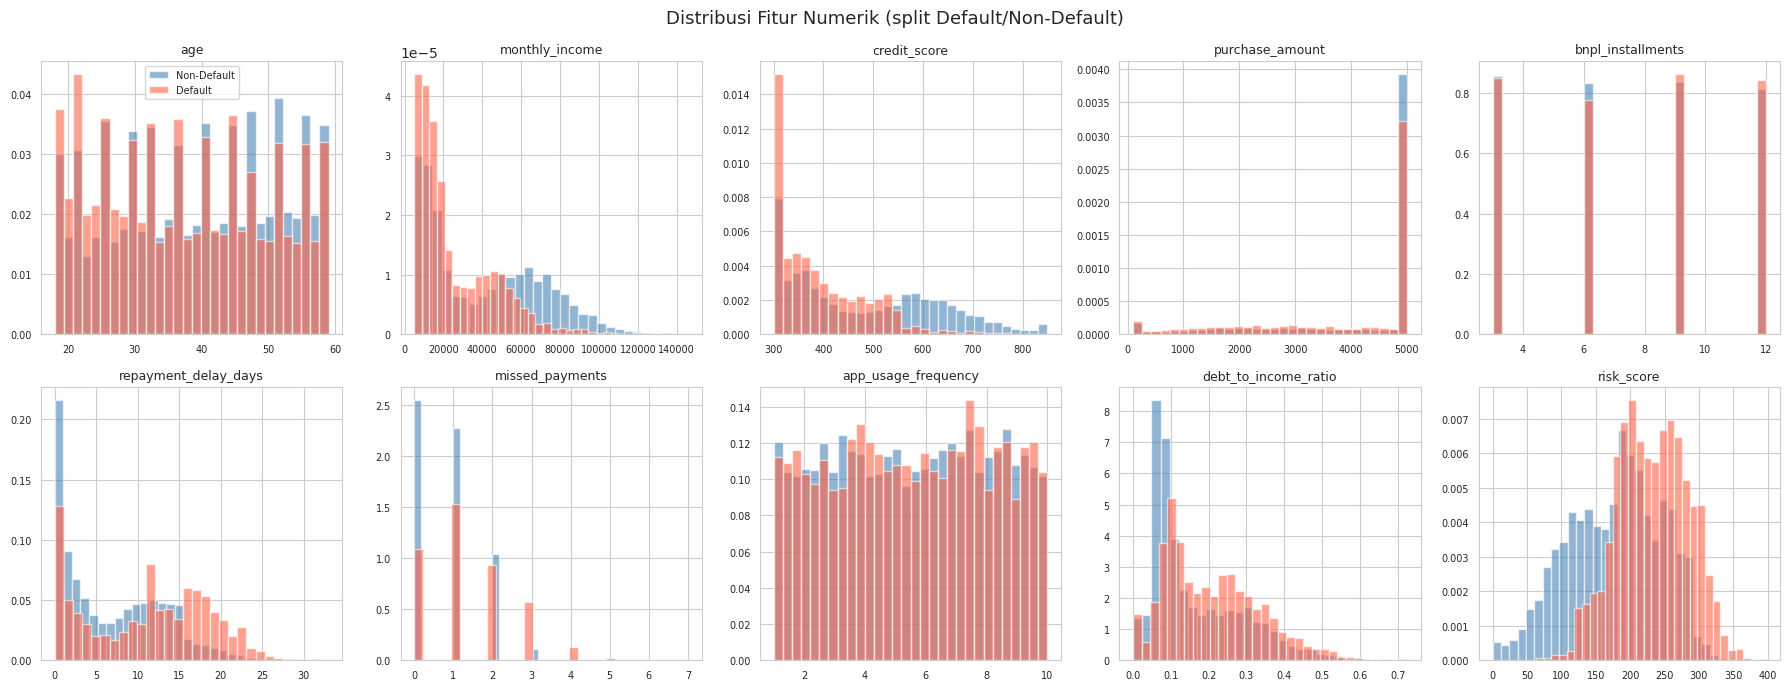

In [121]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Distribusi Fitur Numerik (split Default/Non-Default)", fontsize=13)
df0 = df[df[TARGET] == 0]
df1 = df[df[TARGET] == 1]
for ax, col in zip(axes.flat, NUM_COLS):
    ax.hist(df0[col], bins=30, alpha=0.6, label='Non-Default', color='steelblue', density=True)
    ax.hist(df1[col], bins=30, alpha=0.6, label='Default',     color='tomato',    density=True)
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
axes[0, 0].legend(fontsize=7)
plt.tight_layout()
 

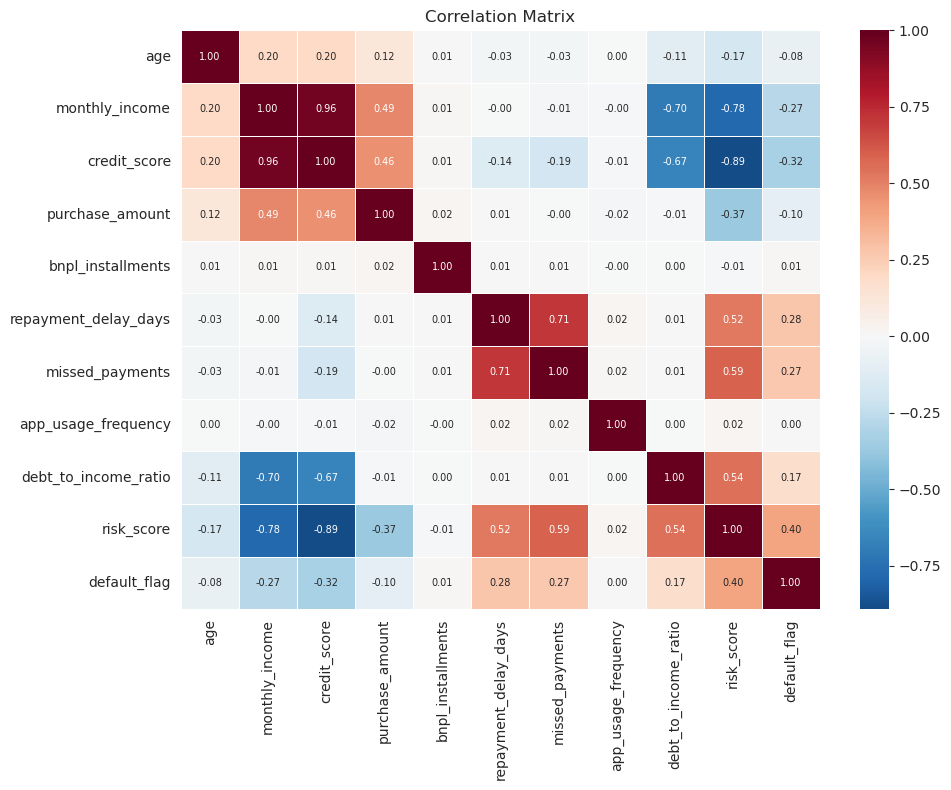

In [122]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[NUM_COLS + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title("Correlation Matrix", fontsize=12)
plt.tight_layout()

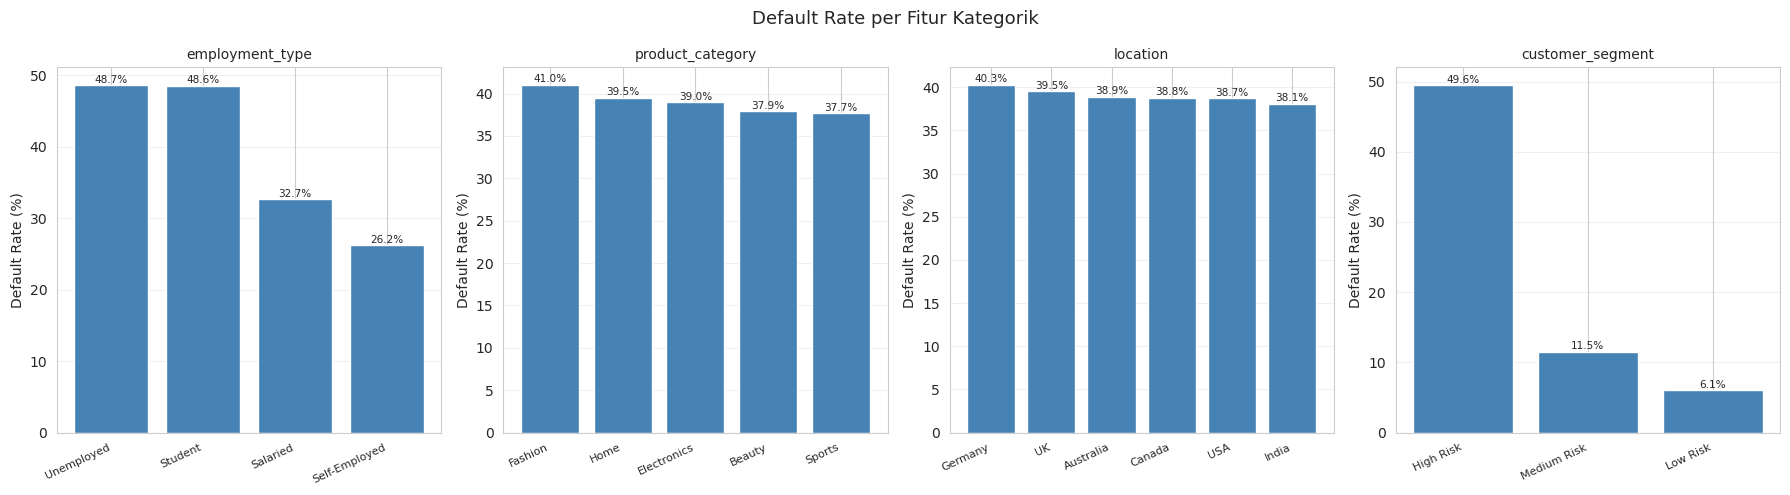

In [123]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Default Rate per Fitur Kategorik", fontsize=13)
for ax, col in zip(axes, CAT_COLS):
    dr = df.groupby(col)[TARGET].mean().sort_values(ascending=False) * 100
    ax.bar(dr.index, dr.values, color='steelblue', edgecolor='white')
    for i, v in enumerate(dr.values):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=7.5)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Default Rate (%)")
    ax.set_xticklabels(dr.index, rotation=25, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

# **5. Data Preprocessing**

In [124]:
print("\n" + "=" * 60)
print("STEP 1 — DROP KOLOM TIDAK RELEVAN")
print("=" * 60)
 
# user_id     : hanya ID, bukan fitur
# transaction_date : hanya 12 unique month (Jan-Des), tidak informatif untuk prediksi
# customer_segment : derived dari risk_score → redundan & potensial data leakage
COLS_TO_DROP = ['user_id', 'transaction_date', 'customer_segment']
df.drop(columns=COLS_TO_DROP, inplace=True)
 
print(f"Kolom yang di-drop: {COLS_TO_DROP}")
print(f"Shape setelah drop: {df.shape}")


STEP 1 — DROP KOLOM TIDAK RELEVAN
Kolom yang di-drop: ['user_id', 'transaction_date', 'customer_segment']
Shape setelah drop: (10345, 14)


In [125]:
print("\n" + "=" * 60)
print("STEP 2 — FEATURE SELECTION")
print("=" * 60)
 
# bnpl_installments  : corr = 0.0122 dengan default_flag
# app_usage_frequency: corr = 0.0039 dengan default_flag
LOW_CORR_COLS = ['bnpl_installments', 'app_usage_frequency']
df.drop(columns=LOW_CORR_COLS, inplace=True)
 
print(f"Kolom dibuang (korelasi ~0 dengan target): {LOW_CORR_COLS}")
print(f"Shape setelah feature selection: {df.shape}")
print(f"Fitur tersisa: {list(df.columns)}")


STEP 2 — FEATURE SELECTION
Kolom dibuang (korelasi ~0 dengan target): ['bnpl_installments', 'app_usage_frequency']
Shape setelah feature selection: (10345, 12)
Fitur tersisa: ['age', 'employment_type', 'monthly_income', 'credit_score', 'purchase_amount', 'product_category', 'repayment_delay_days', 'missed_payments', 'default_flag', 'location', 'debt_to_income_ratio', 'risk_score']


In [126]:
print("\n" + "=" * 60)
print("STEP 3 — HANDLING OUTLIERS (IQR Capping)")
print("=" * 60)
 
# Hanya kolom yang punya outlier signifikan berdasarkan EDA:
# monthly_income (0.24%), debt_to_income_ratio (0.55%), risk_score (0.30%)
OUTLIER_COLS = ['monthly_income', 'debt_to_income_ratio', 'risk_score']
 
for col in OUTLIER_COLS:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"  {col}: {n_before} outlier di-cap ke [{lower:.2f}, {upper:.2f}]")


STEP 3 — HANDLING OUTLIERS (IQR Capping)
  monthly_income: 25 outlier di-cap ke [-52397.85, 119881.80]
  debt_to_income_ratio: 57 outlier di-cap ke [-0.20, 0.55]
  risk_score: 31 outlier di-cap ke [7.80, 396.60]


In [127]:
print("\n" + "=" * 60)
print("STEP 4 — DATA TRANSFORMATION (Log Transform)")
print("=" * 60)
 
# monthly_income: skewness 0.815 → log1p transform
# (purchase_amount tidak di-transform karena ada natural cap di 5000, bukan skew distribusi asli)
skew_before = df['monthly_income'].skew()
df['monthly_income'] = np.log1p(df['monthly_income'])
skew_after = df['monthly_income'].skew()
 
print(f"  monthly_income: skewness {skew_before:.3f} → {skew_after:.3f} (log1p)")


STEP 4 — DATA TRANSFORMATION (Log Transform)
  monthly_income: skewness 0.800 → -0.121 (log1p)


In [128]:
print("\n" + "=" * 60)
print("STEP 5 — ENCODING CATEGORICAL VARIABLES")
print("=" * 60)
 
# One-Hot Encoding: employment_type, product_category, location
# (nominal, tidak ada urutan)
OHE_COLS = ['employment_type', 'product_category', 'location']
df = pd.get_dummies(df, columns=OHE_COLS, drop_first=False, dtype=int)
 
print(f"  One-Hot Encoding: {OHE_COLS}")
print(f"  Shape setelah encoding: {df.shape}")
print(f"  Semua kolom: {list(df.columns)}")
 


STEP 5 — ENCODING CATEGORICAL VARIABLES
  One-Hot Encoding: ['employment_type', 'product_category', 'location']
  Shape setelah encoding: (10345, 24)
  Semua kolom: ['age', 'monthly_income', 'credit_score', 'purchase_amount', 'repayment_delay_days', 'missed_payments', 'default_flag', 'debt_to_income_ratio', 'risk_score', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Student', 'employment_type_Unemployed', 'product_category_Beauty', 'product_category_Electronics', 'product_category_Fashion', 'product_category_Home', 'product_category_Sports', 'location_Australia', 'location_Canada', 'location_Germany', 'location_India', 'location_UK', 'location_USA']


In [129]:
print("\n" + "=" * 60)
print("STEP 6 — PISAH FITUR DAN TARGET")
print("=" * 60)
 
X = df.drop(columns=['default_flag'])
y = df['default_flag']
 
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  Distribusi target:\n{y.value_counts().to_string()}")


STEP 6 — PISAH FITUR DAN TARGET
  X shape: (10345, 23)
  y shape: (10345,)
  Distribusi target:
default_flag
0    6305
1    4040


In [130]:
print("\n" + "=" * 60)
print("STEP 7 — TRAIN / TEST SPLIT (80:20, stratified)")
print("=" * 60)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"  X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"  y_train distribusi:\n{y_train.value_counts().to_string()}")
print(f"  y_test distribusi:\n{y_test.value_counts().to_string()}")


STEP 7 — TRAIN / TEST SPLIT (80:20, stratified)
  X_train: (8276, 23), X_test: (2069, 23)
  y_train distribusi:
default_flag
0    5044
1    3232
  y_test distribusi:
default_flag
0    1261
1     808


In [131]:
print("\n" + "=" * 60)
print("STEP 8 — FEATURE SCALING (StandardScaler)")
print("=" * 60)
 
NUM_COLS_FINAL = ['age', 'monthly_income', 'credit_score', 'purchase_amount',
                  'repayment_delay_days', 'missed_payments', 'debt_to_income_ratio',
                  'risk_score']
 
scaler = StandardScaler()
X_train[NUM_COLS_FINAL] = scaler.fit_transform(X_train[NUM_COLS_FINAL])
X_test[NUM_COLS_FINAL]  = scaler.transform(X_test[NUM_COLS_FINAL])
 
print(f"  Kolom yang di-scale: {NUM_COLS_FINAL}")
print(f"  Scaler fit di train, transform di test.")
print(f"\n  Contoh statistik X_train setelah scaling:")
print(X_train[NUM_COLS_FINAL].describe().loc[['mean', 'std']].round(3).to_string())


STEP 8 — FEATURE SCALING (StandardScaler)
  Kolom yang di-scale: ['age', 'monthly_income', 'credit_score', 'purchase_amount', 'repayment_delay_days', 'missed_payments', 'debt_to_income_ratio', 'risk_score']
  Scaler fit di train, transform di test.

  Contoh statistik X_train setelah scaling:
      age  monthly_income  credit_score  purchase_amount  repayment_delay_days  missed_payments  debt_to_income_ratio  risk_score
mean  0.0             0.0           0.0             -0.0                   0.0              0.0                   0.0         0.0
std   1.0             1.0           1.0              1.0                   1.0              1.0                   1.0         1.0


In [132]:
print("\n" + "=" * 60)
print("STEP 9 — HANDLING IMBALANCED DATA (SMOTE)")
print("=" * 60)
 
print(f"  Sebelum SMOTE — distribusi y_train:\n{y_train.value_counts().to_string()}")
 
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
 
print(f"  Sesudah SMOTE — distribusi y_train:\n{pd.Series(y_train_res).value_counts().to_string()}")
print(f"  X_train shape setelah SMOTE: {X_train_res.shape}")


STEP 9 — HANDLING IMBALANCED DATA (SMOTE)
  Sebelum SMOTE — distribusi y_train:
default_flag
0    5044
1    3232
  Sesudah SMOTE — distribusi y_train:
default_flag
0    5044
1    5044
  X_train shape setelah SMOTE: (10088, 23)


In [133]:
print("\n" + "=" * 60)
print("STEP 11 — DATA VALIDATION")
print("=" * 60)
 
checks = {
    "X_train missing values"  : int(pd.DataFrame(X_train_res).isnull().sum().sum()),
    "X_test missing values"   : int(X_test.isnull().sum().sum()),
    "Infinite values (train)" : int(np.isinf(X_train_res).sum().sum() if hasattr(X_train_res, 'sum') else 0),
    "X_train shape OK"        : X_train_res.shape[1] == X_test.shape[1],
    "y_train balanced (SMOTE)": pd.Series(y_train_res).value_counts()[0] == pd.Series(y_train_res).value_counts()[1],
}
 
all_passed = True
for check, result in checks.items():
    status = "✅" if result == 0 or result is True else "⚠️"
    if result not in (0, True):
        all_passed = False
    print(f"  {status} {check}: {result}")
 
print(f"\n  {'✅ Semua validasi lulus.' if all_passed else '⚠️ Ada validasi yang perlu dicek.'}")
 


STEP 11 — DATA VALIDATION
  ✅ X_train missing values: 0
  ✅ X_test missing values: 0
  ✅ Infinite values (train): 0
  ✅ X_train shape OK: True
  ⚠️ y_train balanced (SMOTE): True

  ✅ Semua validasi lulus.


In [134]:
print("\n" + "=" * 60)
print("STEP 12 — EXPORT PREPROCESSED DATA")
print("=" * 60)

OUT_DIR = 'Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset_Preprocessing'

os.makedirs(OUT_DIR, exist_ok=True)

X_train_df = pd.DataFrame(X_train_res, columns=X_train.columns)
y_train_df = pd.Series(y_train_res, name='default_flag')
X_test_df  = X_test.reset_index(drop=True)
y_test_df  = y_test.reset_index(drop=True)

train_df = pd.concat([X_train_df, y_train_df], axis=1)
test_df  = pd.concat([X_test_df, y_test_df], axis=1)

train_path = os.path.join(OUT_DIR, 'train_preprocessed.csv')
test_path  = os.path.join(OUT_DIR, 'test_preprocessed.csv')

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"  {train_path} — shape: {train_df.shape}")
print(f"  {test_path}  — shape: {test_df.shape}")


STEP 12 — EXPORT PREPROCESSED DATA
  Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset_Preprocessing/train_preprocessed.csv — shape: (10088, 24)
  Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset_Preprocessing/test_preprocessed.csv  — shape: (2069, 24)


In [136]:
print("\n" + "=" * 60)
print("RINGKASAN PREPROCESSING")
print("=" * 60)
print(f"  Raw data             : 10.345 baris, 17 kolom")
print(f"  Kolom di-drop        : user_id, transaction_date, customer_segment")
print(f"  Fitur dibuang        : bnpl_installments, app_usage_frequency (corr ~0)")
print(f"  Outlier capping      : monthly_income, debt_to_income_ratio, risk_score")
print(f"  Log transform        : monthly_income (skew 0.815 → ~0)")
print(f"  Encoding             : One-Hot (employment_type, product_category, location)")
print(f"  Scaling              : StandardScaler (numerik)")
print(f"  Imbalance handling   : SMOTE pada train set")
print(f"  Train set (setelah)  : {train_df.shape}")
print(f"  Test set             : {test_df.shape}")
print(f"  Fitur akhir          : {X_train_df.shape[1]}")


RINGKASAN PREPROCESSING
  Raw data             : 10.345 baris, 17 kolom
  Kolom di-drop        : user_id, transaction_date, customer_segment
  Fitur dibuang        : bnpl_installments, app_usage_frequency (corr ~0)
  Outlier capping      : monthly_income, debt_to_income_ratio, risk_score
  Log transform        : monthly_income (skew 0.815 → ~0)
  Encoding             : One-Hot (employment_type, product_category, location)
  Scaling              : StandardScaler (numerik)
  Imbalance handling   : SMOTE pada train set
  Train set (setelah)  : (10088, 24)
  Test set             : (2069, 24)
  Fitur akhir          : 23
